# 👯 Lesson 3 · Multi-robot VLA rollout + dual-task dataset

This notebook combines everything: two SO-101 arms in the same world, each
driven by **SmolVLA** with its own natural-language instruction, all
captured into a single LeRobot dataset with per-robot joint disambiguation.

The schema looks like:

```
observation.state.names = [
    "alice__shoulder_pan", "alice__shoulder_lift", ...,
    "bob__shoulder_pan",   "bob__shoulder_lift",   ...,
]
```

This is the new feature introduced by this PR — you can now train a single
dual-agent policy from one multi-robot rollout without column collisions.

## 1 · Setup

In [1]:
import os, tempfile, pathlib, time, json
os.environ['STRANDS_TRUST_REMOTE_CODE'] = 'true'
os.environ.setdefault('MUJOCO_GL', 'glfw')

from strands_robots.simulation import create_simulation
from strands_robots.policies import create_policy
from IPython.display import display, Image as IPyImage, Video

def show(sim, cam, w=480, h=360):
    r = sim.render(camera_name=cam, width=w, height=h)
    ib = next(c for c in r["content"] if "image" in c)
    b = ib["image"]["source"]["bytes"]
    display(IPyImage(data=b if isinstance(b, (bytes, bytearray)) else __import__('base64').b64decode(b)))


## 2 · Dual-robot world

robots: ['alice', 'bob']
alice joints: ['shoulder_pan', 'shoulder_lift', 'elbow_flex', 'wrist_flex', 'wrist_roll', 'gripper']
bob joints  : ['shoulder_pan', 'shoulder_lift', 'elbow_flex', 'wrist_flex', 'wrist_roll', 'gripper']


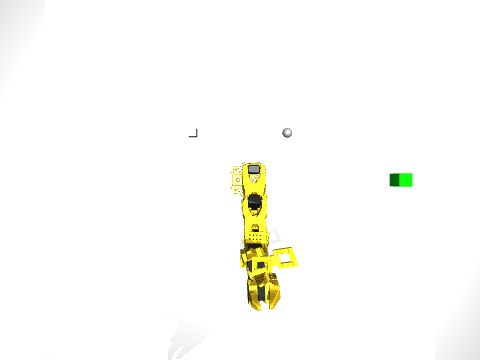

In [2]:
sim = create_simulation("mujoco")
sim.create_world(timestep=0.002, gravity=[0, 0, -9.81])

sim.add_robot("alice", data_config="so101", position=[-0.25, 0, 0])
sim.add_robot("bob",   data_config="so101", position=[ 0.25, 0, 0])

sim.add_object("red_cube",  shape="box",    size=[0.025]*3,
               position=[-0.15, 0.15, 0.05], rgba=[1, 0, 0, 1])
sim.add_object("blue_ball", shape="sphere", size=[0.03]*3,
               position=[ 0.15, 0.15, 0.05], rgba=[0, 0, 1, 1])

sim.add_camera("top", position=[0, 0, 1.0], target=[0, 0.15, 0.05])
sim.step(n_steps=50)

print("robots:", list(sim._world.robots.keys()))
print("alice joints:", sim.robot_joint_names("alice"))
print("bob joints  :", sim.robot_joint_names("bob"))
show(sim, "top")

## 3 · Load SmolVLA once, bind it to each robot's joint order

In [3]:
print("loading SmolVLA (shared base)...")
t0 = time.time()

# Each robot needs a policy with its own state-key binding because
# set_robot_state_keys is stateful. Creating two policy *instances*
# with the same checkpoint is cheap after the first load (HF cache).
policy_alice = create_policy("lerobot_local",
                             pretrained_name_or_path="lerobot/smolvla_base",
                             device="mps", actions_per_step=1)
policy_alice.set_robot_state_keys(sim.robot_joint_names("alice"))

policy_bob = create_policy("lerobot_local",
                           pretrained_name_or_path="lerobot/smolvla_base",
                           device="mps", actions_per_step=1)
policy_bob.set_robot_state_keys(sim.robot_joint_names("bob"))

print(f"loaded in {time.time()-t0:.1f}s (2 instances, shared weights in HF cache)")

loading SmolVLA (shared base)...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

loaded in 18.5s (2 instances, shared weights in HF cache)


## 4 · One recording session, two rollouts, two tasks

In [4]:
tmpdir = pathlib.Path(tempfile.mkdtemp(prefix="multi_vla_"))

sim.start_recording(repo_id="local/dual_task_vla",
                    task="pick_red_and_blue",
                    fps=20, root=str(tmpdir), overwrite=True)

print("rollout 1: alice → red cube")
t0 = time.time()
r = sim.run_policy("alice", policy_object=policy_alice,
                   instruction="grasp the red cube",
                   duration=2.0, control_frequency=20.0)
print(f"  {r['status']} in {time.time()-t0:.1f}s")

print("\nrollout 2: bob → blue ball")
t0 = time.time()
r = sim.run_policy("bob", policy_object=policy_bob,
                   instruction="grasp the blue ball",
                   duration=2.0, control_frequency=20.0)
print(f"  {r['status']} in {time.time()-t0:.1f}s")

stop = sim.stop_recording()
print(f"\nstop_recording: {stop['status']}")

rollout 1: alice → red cube


  success in 9.1s

rollout 2: bob → blue ball


  success in 8.8s


Map:   0%|          | 0/80 [00:00<?, ? examples/s]


stop_recording: success


## 5 · 🎬 Watch both rollouts

Single top-down camera captures both robots' behaviors across the whole
dual-rollout episode.

In [5]:
top_mp4 = tmpdir / "videos" / "observation.images.top" / "chunk-000" / "file-000.mp4"
print(f"top view: {top_mp4.stat().st_size:,} bytes")
display(Video(str(top_mp4), embed=True, html_attributes="controls loop autoplay"))

# Per-robot wrist cams — what each VLA actually saw
for robot in ["alice", "bob"]:
    mp4 = tmpdir / "videos" / f"observation.images.{robot}__wrist_cam" / "chunk-000" / "file-000.mp4"
    if mp4.exists():
        print(f"\n{robot} wrist cam: {mp4.stat().st_size:,} bytes")
        display(Video(str(mp4), embed=True, html_attributes="controls loop"))

top view: 258,711 bytes



alice wrist cam: 226,427 bytes



bob wrist cam: 236,812 bytes


## 6 · Verify the multi-robot schema

The heart of this PR. `info.json` → `observation.state.names` should contain
`alice__shoulder_pan` … `bob__shoulder_pan` etc., not flat names.

In [6]:
info = json.loads((tmpdir / "meta" / "info.json").read_text())
print(f"episodes         : {info['total_episodes']}")
print(f"frames (alice+bob): {info['total_frames']}")
print(f"fps              : {info['fps']}")

state_names = info["features"]["observation.state"]["names"]
action_names = info["features"]["action"]["names"]
assert state_names == action_names  # same ordering

print("\n-- observation.state.names (12 = 6 alice + 6 bob) --")
for n in state_names:
    print(f"  {n}")

alice_count = sum(1 for n in state_names if n.startswith("alice__"))
bob_count   = sum(1 for n in state_names if n.startswith("bob__"))
print(f"\nalice__*: {alice_count}   bob__*: {bob_count}")
assert alice_count == 6 and bob_count == 6

# Cameras
cams = [k for k in info["features"] if k.startswith("observation.images.")]
print(f"\ncamera features ({len(cams)}):")
for c in cams:
    print(f"  {c}")

episodes         : 1
frames (alice+bob): 80
fps              : 20

-- observation.state.names (12 = 6 alice + 6 bob) --
  alice__shoulder_pan
  alice__shoulder_lift
  alice__elbow_flex
  alice__wrist_flex
  alice__wrist_roll
  alice__gripper
  bob__shoulder_pan
  bob__shoulder_lift
  bob__elbow_flex
  bob__wrist_flex
  bob__wrist_roll
  bob__gripper

alice__*: 6   bob__*: 6

camera features (4):
  observation.images.default
  observation.images.top
  observation.images.alice__wrist_cam
  observation.images.bob__wrist_cam


## 7 · Parquet — frames from both rollouts in one episode

In [7]:
import pandas as pd, numpy as np

parq = next((tmpdir / "data").rglob("*.parquet"))
df = pd.read_parquet(parq)
print(f"rows: {len(df)}   episodes: {df['episode_index'].unique().tolist()}")
print(f"columns: {list(df.columns)}\n")

# Split by time into alice-half and bob-half (rollouts run back-to-back)
actions = np.stack([np.asarray(a, dtype=np.float32) for a in df["action"].values])
print(f"action matrix shape: {actions.shape}  (expected 12 cols for 2 robots × 6 joints)")

rows: 80   episodes: [0]
columns: ['observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']

action matrix shape: (80, 12)  (expected 12 cols for 2 robots × 6 joints)


## 8 · Plot both robots' action trajectories

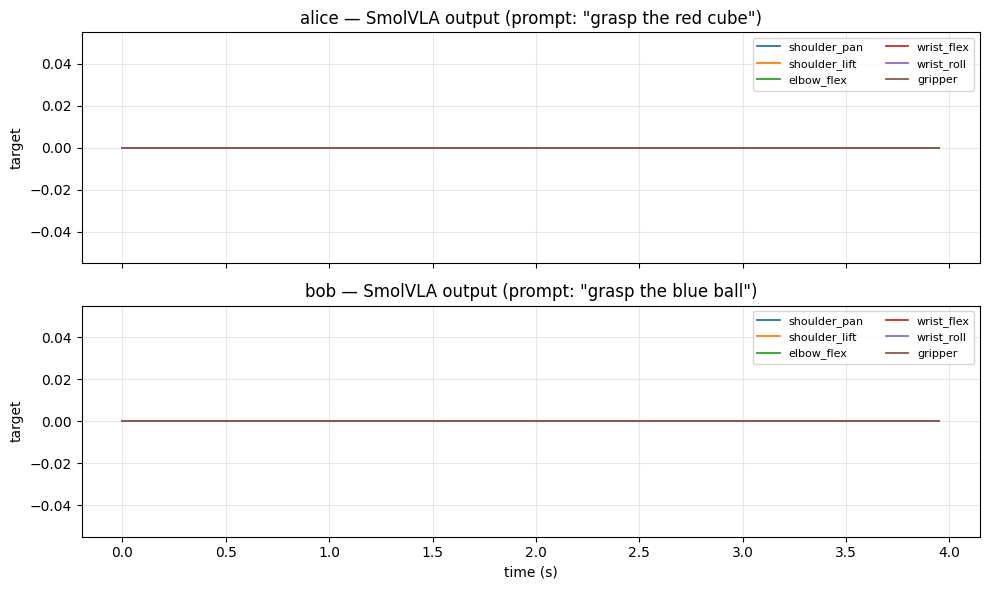

In [8]:
import matplotlib; # matplotlib uses default inline backend in notebooks
import matplotlib.pyplot as plt

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t = df["timestamp"].values

# alice columns 0..5
for i in range(6):
    ax_a.plot(t, actions[:, i], label=state_names[i].replace("alice__",""), linewidth=1.3)
ax_a.set_title('alice — SmolVLA output (prompt: "grasp the red cube")')
ax_a.legend(loc="upper right", fontsize=8, ncol=2)
ax_a.grid(alpha=0.3)
ax_a.set_ylabel("target")

# bob columns 6..11
for i in range(6, 12):
    ax_b.plot(t, actions[:, i], label=state_names[i].replace("bob__",""), linewidth=1.3)
ax_b.set_title('bob — SmolVLA output (prompt: "grasp the blue ball")')
ax_b.legend(loc="upper right", fontsize=8, ncol=2)
ax_b.grid(alpha=0.3)
ax_b.set_xlabel("time (s)")
ax_b.set_ylabel("target")

plt.tight_layout()
plt.show()

## 9 · Sanity check: single-robot scenes keep flat names

Control case — backwards-compat for existing pipelines.

In [9]:
sim.destroy()

single = create_simulation("mujoco")
single.create_world()
single.add_robot("arm", data_config="so101", position=[0, 0, 0])
single.step(n_steps=5)

tmp2 = pathlib.Path(tempfile.mkdtemp(prefix="single_"))
single.start_recording(repo_id="local/single", task="solo",
                       fps=20, root=str(tmp2), overwrite=True)

from strands_robots.policies.mock import MockPolicy
p = MockPolicy(); p.set_robot_state_keys(single.robot_joint_names("arm"))
single.run_policy("arm", policy_object=p, instruction="demo",
                  duration=0.5, control_frequency=20.0)
single.stop_recording()

info2 = json.loads((tmp2 / "meta" / "info.json").read_text())
state_names2 = info2["features"]["observation.state"]["names"]
print("single-robot state.names:")
for n in state_names2:
    print(f"  {n}")
assert all("__" not in n for n in state_names2)
print("\n✅ single-robot keeps flat names — no breaking change")

single.destroy()

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

single-robot state.names:
  shoulder_pan
  shoulder_lift
  elbow_flex
  wrist_flex
  wrist_roll
  gripper

✅ single-robot keeps flat names — no breaking change


{'status': 'success', 'content': [{'text': '🗑️ World destroyed.'}]}

---
### Why this matters

Before this PR, a two-robot LeRobot recording would produce a state vector
with **colliding joint names** — both `shoulder_pan` columns merged into one.
Training a dual-agent VLA required custom post-processing or throwing out
the schema.

Now multi-robot works out-of-the-box:
- Two-robot scenes → `{robot}__{joint}` prefixed columns
- One-robot scenes → flat names (backwards-compat)
- All wired through the existing `start_recording` / `run_policy` APIs

### Integration test locking this behavior

[`tests_integ/simulation/test_multi_robot_tasks.py`](../blob/feat/mujoco-backend/tests_integ/simulation/test_multi_robot_tasks.py)
runs the same flow without notebooks, asserting both the `alice__*` schema
and the flat-name control case.

### Sources

* Feature: [`strands_robots/simulation/mujoco/recording.py#L68-L90`](../blob/feat/mujoco-backend/strands_robots/simulation/mujoco/recording.py)
* LeRobot v3 writer: [`strands_robots/dataset_recorder.py`](../blob/feat/mujoco-backend/strands_robots/dataset_recorder.py)
* Policy runner: [`strands_robots/simulation/policy_runner.py`](../blob/feat/mujoco-backend/strands_robots/simulation/policy_runner.py)